In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from collections import Counter

In [10]:
df = pd.read_csv('diabetes_dataset00.csv')
print(df.shape)
df.head()

(70000, 34)


,Target,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
0,Steroid-Induced Diabetes,Positive,Negative,No,Present,40,44,38,High,Healthy,...,76,No,No,Positive,3,Normal,56,Ketones Present,2629,No
1,Neonatal Diabetes Mellitus (NDM),Positive,Negative,No,Present,13,1,17,High,Healthy,...,60,Yes,No,Negative,1,Normal,28,Glucose Present,1881,Yes
2,Prediabetic,Positive,Positive,Yes,Present,27,36,24,High,Unhealthy,...,80,Yes,No,Negative,1,Abnormal,55,Ketones Present,3622,Yes
3,Type 1 Diabetes,Negative,Positive,No,Present,8,7,16,Low,Unhealthy,...,89,Yes,No,Positive,2,Abnormal,60,Ketones Present,3542,No
4,Wolfram Syndrome,Negative,Negative,Yes,Present,17,10,17,High,Healthy,...,41,No,No,Positive,1,Normal,24,Protein Present,1770,No


In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print("Total missing value:", missing.sum(), f"({missing_pct.sum():.2f}%)")

dup_count = df.duplicated().sum()
print(f"Baris duplikat: {dup_count} ({dup_count/len(df)*100:.2f}%)")

Total missing value: 0 (0.00%)
Baris duplikat: 0 (0.00%)


In [12]:
cat_cols_check = df.select_dtypes(include=['object']).columns.tolist()
cat_cols_check.remove('Target')

for col in cat_cols_check:

    print(col, ':', sorted([str(x) for x in df[col].unique()]))

Genetic Markers : ['Negative', 'Positive']
Autoantibodies : ['Negative', 'Positive']
Family History : ['No', 'Yes']
Environmental Factors : ['Absent', 'Present']
Physical Activity : ['High', 'Low', 'Moderate']
Dietary Habits : ['Healthy', 'Unhealthy']
Ethnicity : ['High Risk', 'Low Risk']
Socioeconomic Factors : ['High', 'Low', 'Medium']
Smoking Status : ['Non-Smoker', 'Smoker']
Alcohol Consumption : ['High', 'Low', 'Moderate']
Glucose Tolerance Test : ['Abnormal', 'Normal']
History of PCOS : ['No', 'Yes']
Previous Gestational Diabetes : ['No', 'Yes']
Pregnancy History : ['Complications', 'Normal']
Cystic Fibrosis Diagnosis : ['No', 'Yes']
Steroid Use History : ['No', 'Yes']
Genetic Testing : ['Negative', 'Positive']
Liver Function Tests : ['Abnormal', 'Normal']
Urine Test : ['Glucose Present', 'Ketones Present', 'Normal', 'Protein Present']
Early Onset Symptoms : ['No', 'Yes']


In [13]:
num_cols_check = df.select_dtypes(exclude=['object']).columns.tolist()

outlier_summary = {}
for col in num_cols_check:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = {'jumlah': len(outliers), 'persen': round(len(outliers)/len(df)*100, 2)}

outlier_df = pd.DataFrame(outlier_summary).T.sort_values('persen', ascending=False)
print(outlier_df)

                              jumlah  persen
Pulmonary Function            1206.0    1.72
Waist Circumference            522.0    0.75
BMI                              0.0    0.00
Age                              0.0    0.00
Insulin Levels                   0.0    0.00
Cholesterol Levels               0.0    0.00
Blood Pressure                   0.0    0.00
Weight Gain During Pregnancy     0.0    0.00
Blood Glucose Levels             0.0    0.00
Pancreatic Health                0.0    0.00
Neurological Assessments         0.0    0.00
Digestive Enzyme Levels          0.0    0.00
Birth Weight                     0.0    0.00


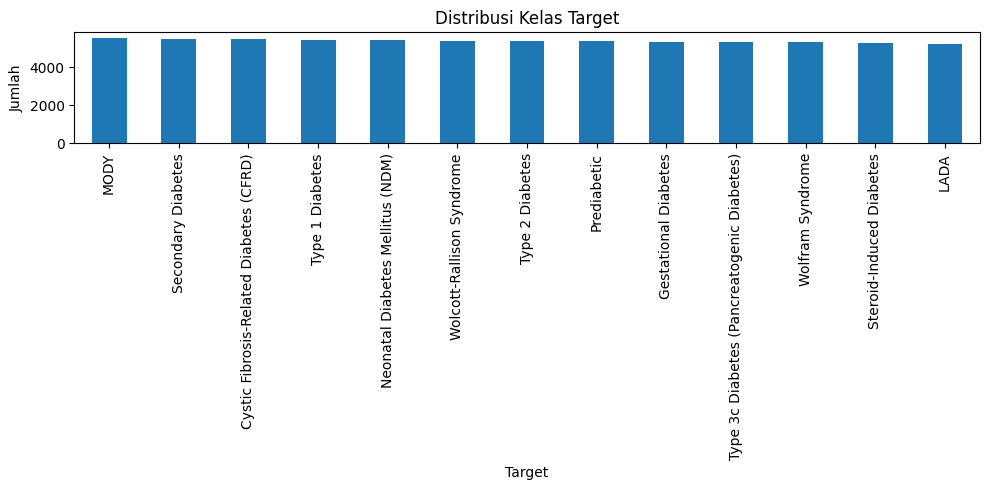

                                            jumlah  persen
Target                                                    
MODY                                          5553    7.93
Secondary Diabetes                            5479    7.83
Cystic Fibrosis-Related Diabetes (CFRD)       5464    7.81
Type 1 Diabetes                               5446    7.78
Neonatal Diabetes Mellitus (NDM)              5408    7.73
Wolcott-Rallison Syndrome                     5400    7.71
Type 2 Diabetes                               5397    7.71
Prediabetic                                   5376    7.68
Gestational Diabetes                          5344    7.63
Type 3c Diabetes (Pancreatogenic Diabetes)    5320    7.60
Wolfram Syndrome                              5315    7.59
Steroid-Induced Diabetes                      5275    7.54
LADA                                          5223    7.46


In [14]:
plt.figure(figsize=(10,5))
df['Target'].value_counts().plot(kind='bar')
plt.title('Distribusi Kelas Target')
plt.ylabel('Jumlah')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

target_dist = df['Target'].value_counts()
print(pd.DataFrame({'jumlah': target_dist, 'persen': (target_dist/len(df)*100).round(2)}))

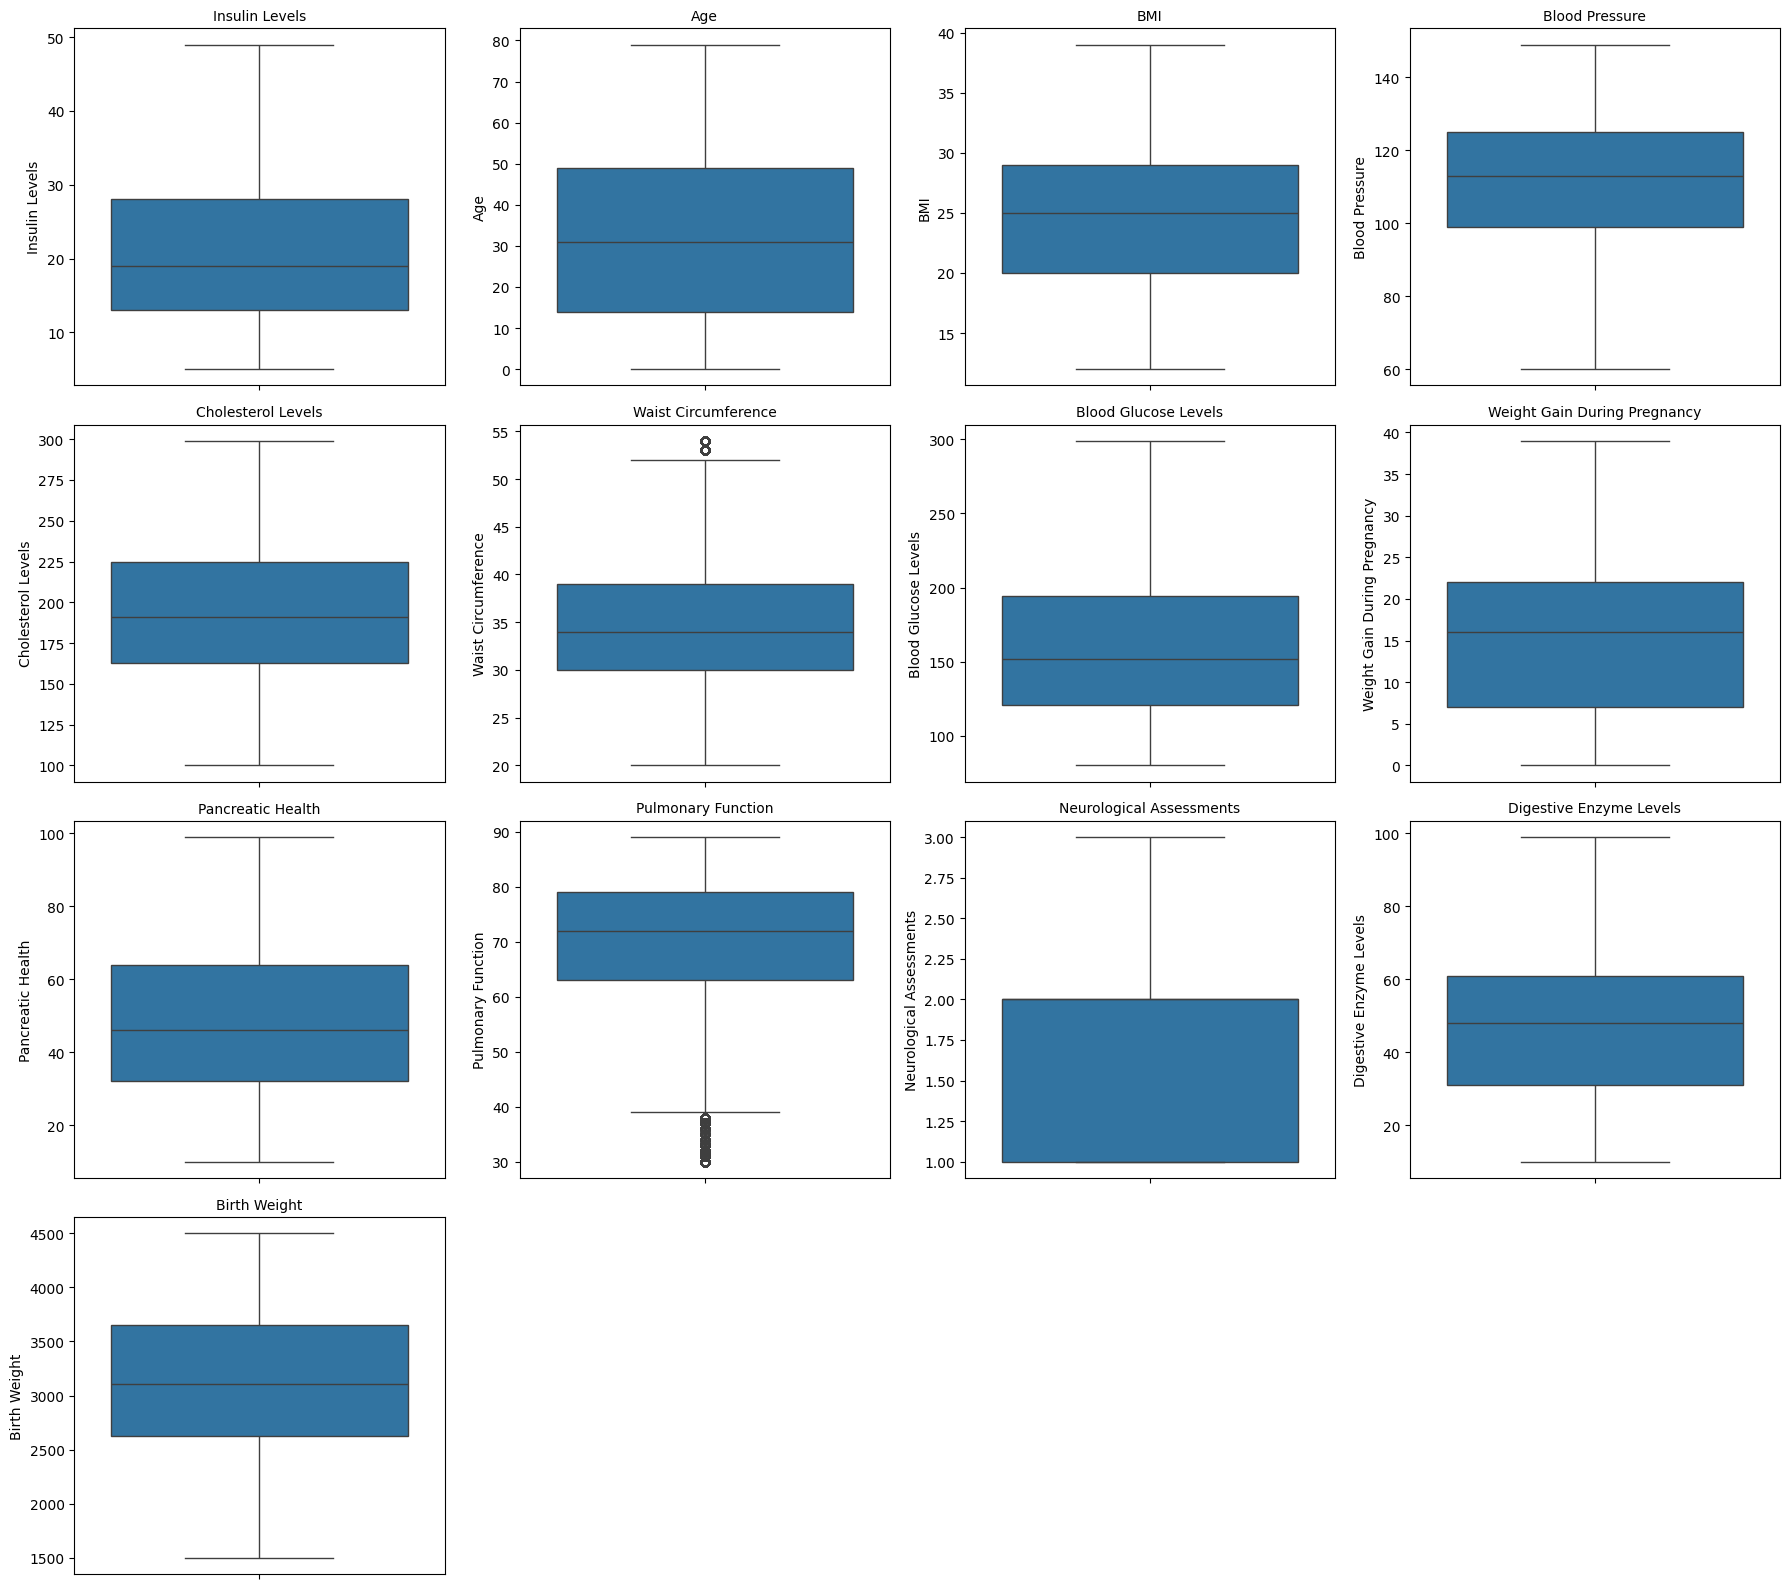

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(18,16))
axes = axes.flatten()
for i, col in enumerate(num_cols_check):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
for j in range(len(num_cols_check), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

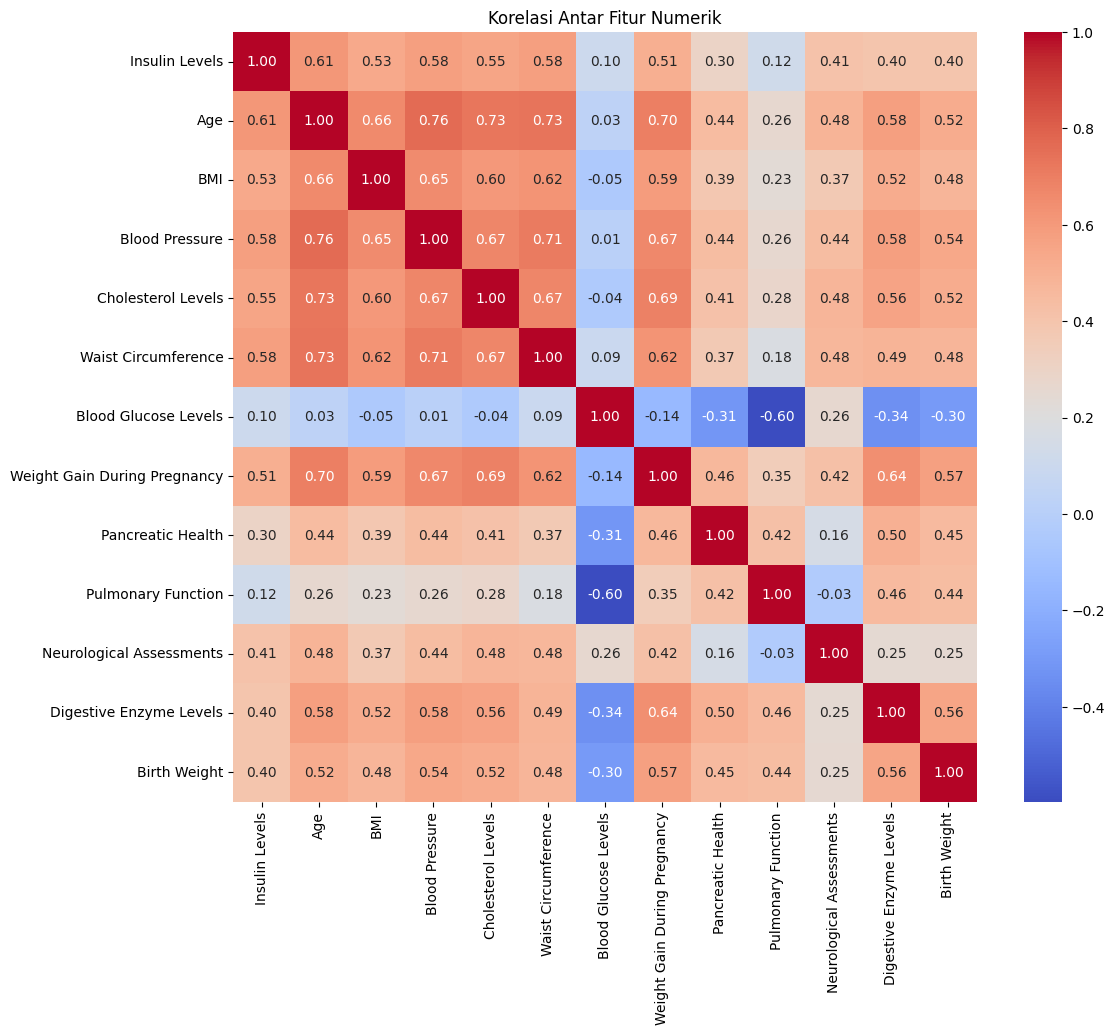

In [16]:
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols_check].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

In [17]:
X = df.drop(columns=['Target'])
y = df['Target']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print(f"Kategorikal: {len(cat_cols)}, Numerikal: {len(num_cols)}")

Kategorikal: 20, Numerikal: 13


In [18]:
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print("Kelas target:", le_target.classes_)

Kelas target: ['Cystic Fibrosis-Related Diabetes (CFRD)' 'Gestational Diabetes' 'LADA'
 'MODY' 'Neonatal Diabetes Mellitus (NDM)' 'Prediabetic'
 'Secondary Diabetes' 'Steroid-Induced Diabetes' 'Type 1 Diabetes'
 'Type 2 Diabetes' 'Type 3c Diabetes (Pancreatogenic Diabetes)'
 'Wolcott-Rallison Syndrome' 'Wolfram Syndrome']


In [19]:
ordinal_cols = ['Physical Activity', 'Socioeconomic Factors', 'Alcohol Consumption']
oe = OrdinalEncoder(categories=[
    ['Low', 'Moderate', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Moderate', 'High'],
])
X[ordinal_cols] = oe.fit_transform(X[ordinal_cols])
X[ordinal_cols].head()

,Physical Activity,Socioeconomic Factors,Alcohol Consumption
0,2.0,1.0,2.0
1,2.0,2.0,1.0
2,2.0,1.0,2.0
3,0.0,2.0,1.0
4,2.0,0.0,1.0


In [20]:
X = pd.get_dummies(X, columns=['Urine Test'])
print("Total kolom setelah one-hot:", X.shape[1])

Total kolom setelah one-hot: 36


In [21]:
cat_cols = [c for c in cat_cols if c not in ordinal_cols + ['Urine Test']]
encoders_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders_dict[col] = le
print("Kolom biner ter-encode:", cat_cols)

Kolom biner ter-encode: ['Genetic Markers', 'Autoantibodies', 'Family History', 'Environmental Factors', 'Dietary Habits', 'Ethnicity', 'Smoking Status', 'Glucose Tolerance Test', 'History of PCOS', 'Previous Gestational Diabetes', 'Pregnancy History', 'Cystic Fibrosis Diagnosis', 'Steroid Use History', 'Genetic Testing', 'Liver Function Tests', 'Early Onset Symptoms']


In [22]:
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
print("Scaling selesai.")

Scaling selesai.


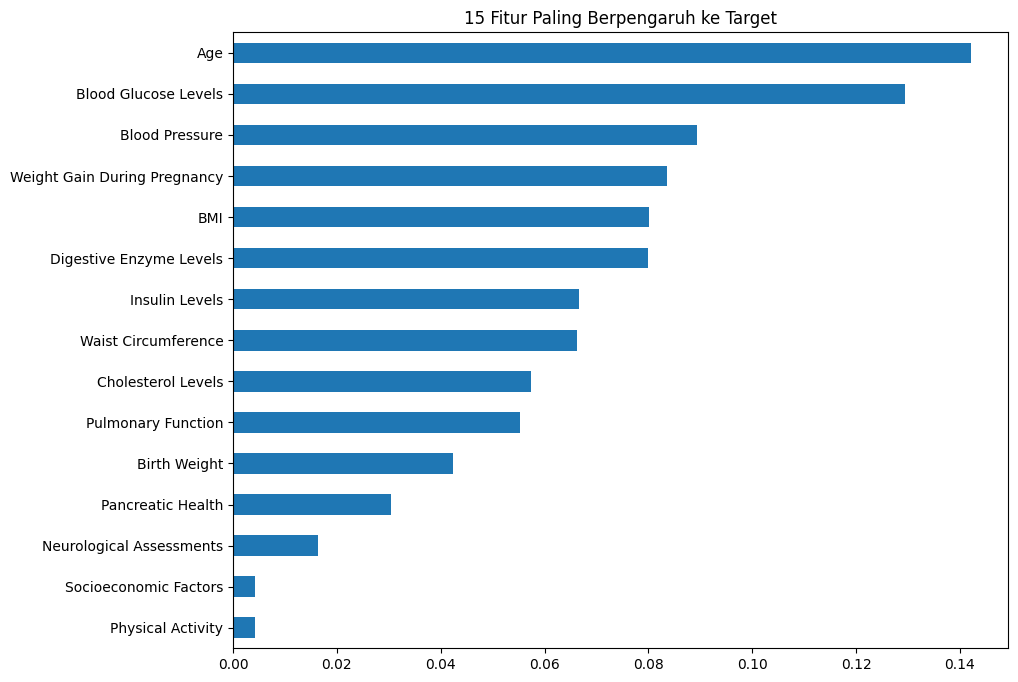

Age                              0.142190
Blood Glucose Levels             0.129407
Blood Pressure                   0.089446
Weight Gain During Pregnancy     0.083596
BMI                              0.080192
Digestive Enzyme Levels          0.079870
Insulin Levels                   0.066605
Waist Circumference              0.066190
Cholesterol Levels               0.057371
Pulmonary Function               0.055252
Birth Weight                     0.042376
Pancreatic Health                0.030425
Neurological Assessments         0.016326
Socioeconomic Factors            0.004273
Physical Activity                0.004184
Alcohol Consumption              0.004159
Early Onset Symptoms             0.002591
Family History                   0.002582
Cystic Fibrosis Diagnosis        0.002582
Previous Gestational Diabetes    0.002548
Glucose Tolerance Test           0.002543
Dietary Habits                   0.002530
Environmental Factors            0.002529
Pregnancy History                0

In [23]:
from sklearn.ensemble import RandomForestClassifier as RFC_temp
temp_model = RFC_temp(n_estimators=50, random_state=42, n_jobs=-1)
temp_model.fit(X, y_encoded)

importances = pd.Series(temp_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importances.head(15).plot(kind='barh')
plt.title('15 Fitur Paling Berpengaruh ke Target')
plt.gca().invert_yaxis()
plt.show()
print(importances)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (56000, 36)  Test: (14000, 36)


In [25]:
print("Distribusi kelas di y_train:", Counter(y_train))

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Sesudah SMOTE:", Counter(y_train_res))

Distribusi kelas di y_train: Counter({np.int64(3): 4442, np.int64(6): 4383, np.int64(0): 4371, np.int64(8): 4357, np.int64(4): 4326, np.int64(11): 4320, np.int64(9): 4318, np.int64(5): 4301, np.int64(1): 4275, np.int64(10): 4256, np.int64(12): 4252, np.int64(7): 4220, np.int64(2): 4179})
Sesudah SMOTE: Counter({np.int64(6): 4442, np.int64(3): 4442, np.int64(2): 4442, np.int64(11): 4442, np.int64(9): 4442, np.int64(12): 4442, np.int64(0): 4442, np.int64(1): 4442, np.int64(8): 4442, np.int64(7): 4442, np.int64(4): 4442, np.int64(10): 4442, np.int64(5): 4442})


In [26]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(random_state=42),
}

results = {}
trained_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro')
    results[name] = {'accuracy': acc, 'f1_macro': f1}
    trained_models[name] = model
    print(f"{name}: acc={acc:.4f}, f1_macro={f1:.4f}")

results_df = pd.DataFrame(results).T.sort_values('f1_macro', ascending=False)
print(results_df)

Random Forest: acc=0.9041, f1_macro=0.9031
Decision Tree: acc=0.8651, f1_macro=0.8652
KNN: acc=0.6466, f1_macro=0.6448
SVM: acc=0.8074, f1_macro=0.8067
               accuracy  f1_macro
Random Forest  0.904071  0.903080
Decision Tree  0.865071  0.865182
SVM            0.807429  0.806747
KNN            0.646571  0.644808


In [27]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"Model terbaik: {best_model_name}")

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Model terbaik: Random Forest
                                            precision    recall  f1-score   support

   Cystic Fibrosis-Related Diabetes (CFRD)       0.99      0.92      0.95      1093
                      Gestational Diabetes       0.90      0.94      0.92      1069
                                      LADA       0.97      0.93      0.95      1044
                                      MODY       0.96      0.83      0.89      1111
          Neonatal Diabetes Mellitus (NDM)       1.00      1.00      1.00      1082
                               Prediabetic       0.96      1.00      0.98      1075
                        Secondary Diabetes       0.81      0.79      0.80      1096
                  Steroid-Induced Diabetes       0.82      0.83      0.83      1055
                           Type 1 Diabetes       0.85      1.00      0.92      1089
                           Type 2 Diabetes       0.90      0.71      0.79      1079
Type 3c Diabetes (Pancreatogenic Diabetes)    

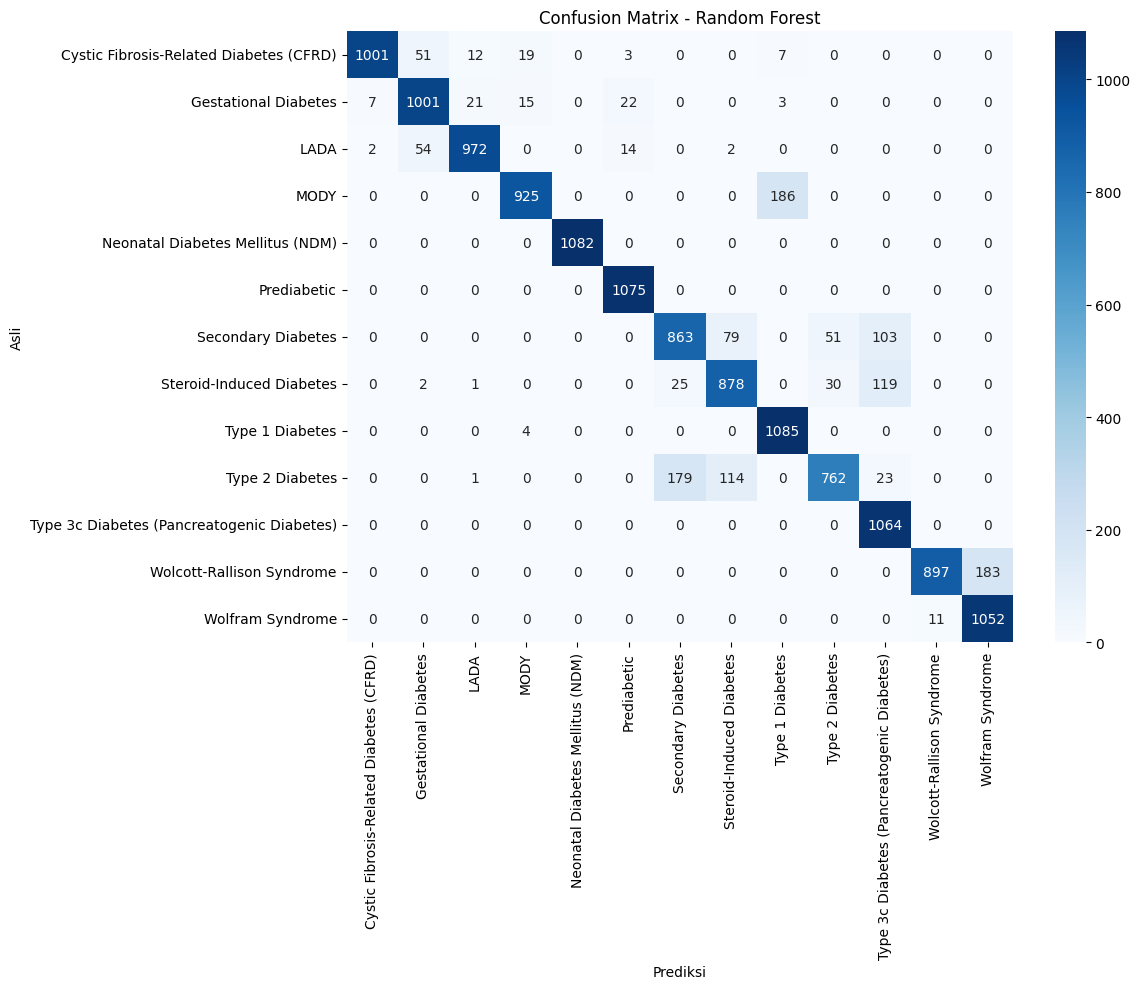

In [28]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le_target.classes_, yticklabels=le_target.classes_, cmap='Blues')
plt.xlabel('Prediksi'); plt.ylabel('Asli')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import GridSearchCV

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100],
        'max_depth': [20, None],
    }
    grid = GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid,
        cv=2,
        scoring='f1_macro',
        n_jobs=1
    )
    grid.fit(X_train_res, y_train_res)
    print("Best params:", grid.best_params_)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Best params: {'max_depth': 20, 'n_estimators': 100}
                                            precision    recall  f1-score   support

   Cystic Fibrosis-Related Diabetes (CFRD)       1.00      0.91      0.95      1093
                      Gestational Diabetes       0.90      0.93      0.92      1069
                                      LADA       0.96      0.93      0.94      1044
                                      MODY       0.96      0.83      0.89      1111
          Neonatal Diabetes Mellitus (NDM)       1.00      1.00      1.00      1082
                               Prediabetic       0.96      1.00      0.98      1075
                        Secondary Diabetes       0.80      0.79      0.80      1096
                  Steroid-Induced Diabetes       0.82      0.85      0.83      1055
                           Type 1 Diabetes       0.84      1.00      0.91      1089
                           Type 2 Diabetes       0.93      0.70      0.80      1079
Type 3c Diabetes (Pancr

In [30]:
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_target, 'le_target.pkl')
joblib.dump(encoders_dict, 'encoders_dict.pkl')
joblib.dump(oe, 'ordinal_encoder.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

print("Semua file .pkl berhasil dibuat!")
print("Model terbaik:", best_model_name)

Semua file .pkl berhasil dibuat!
Model terbaik: Random Forest


In [32]:


print("Current number of features in X after One-Hot Encoding:", X.shape[1])

# Display the one-hot encoded 'Urine Test' columns
display(X[['Urine Test_Glucose Present', 'Urine Test_Ketones Present',
           'Urine Test_Protein Present', 'Urine Test_Normal']].head())

Current number of features in X after One-Hot Encoding: 36


,Urine Test_Glucose Present,Urine Test_Ketones Present,Urine Test_Protein Present,Urine Test_Normal
0,False,True,False,False
1,True,False,False,False
2,False,True,False,False
3,False,True,False,False
4,False,False,True,False
